debug code

In [2]:
import torch
from PIL import Image
from torchvision.models.detection.ssd import SSD300_VGG16_Weights

from pathlib import Path

import numpy as np
import matplotlib.lines as mlines
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn import metrics
# import matplotlib.patches as patches
from copy import deepcopy
import skimage
from skimage.io import imread
import scipy
# import basicpy
from tqdm import tqdm
import geopandas as gpd
import torchmetrics

import models.image_datamodule
import models.embeddings_datamodule
from util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from util import dataloading as dl
from util import postprocessing as pp
# from SSD_model import SSD
# from util.samos import SAMOS
# from util.ssd import SSDPredictor
# from util.FasterRCNN import FasterRCNNPredictor
# from util.cellpose import Cellpose
# from util.gt_sam import GroundTruthSAM
from util.pred_with_sam import PredictionSAM

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Metric evaluations

In [3]:
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')

##### copy filenames to correct locations

In [2]:
import shutil

In [ ]:
cellpose_models = [
    # 'cellpose_diam_[None]',
    # 'cellpose_diam_[30]',
    # 'cellpose_diam_[100]',
    # 'cellpose_diam_[300]',
    # 'cellpose_diam_[100,300]',
    'SSD_objects_2024_sam1',
    'SSD_objects_2025_sam1',
]
for model_name in cellpose_models:
    (results_dir / model_name).mkdir(exist_ok=True)

for file in (results_dir).glob('*.csv'):
    print(file)

    # Get current model name
    curr_model_name = None
    for model_name in cellpose_models:
        if file.name.startswith(model_name):
            curr_model_name = model_name
            break

    # Define output file patch
    outfile = results_dir / curr_model_name / file.name.replace(f'{curr_model_name}_', '', 1)
    print(outfile)
    assert not outfile.exists(), outfile
    # shutil.move(file, outfile)


/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results/SSD_objects_2025_sam1_stiched_segmentation_metrics_NewData_all.csv
/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results/SSD_objects_2025_sam1/stiched_segmentation_metrics_NewData_all.csv
/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results/SSD_objects_2024_sam1_stiched_segmentation_metrics_NewData_all.csv
/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results/SSD_objects_2024_sam1/stiched_segmentation_metrics_NewData_all.csv
/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results/SSD_objects_2024_sam1_mean_detection_AP_MultiOrg_test_macros.csv
/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results/SSD_objects_2024_sam1/mean_detection_AP_MultiOrg_test_macros.csv
/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results/SSD_objects_2024_sam1_mean_detection_metrics_OrganoID_test_C.csv
/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results/SSD_objects_2024_sam1/mea

##### Evaluate SAM & SAM2 segmentation performance depending on the box noise  

In [ ]:
# Segmentation metrics: MASD, ASSD, hausdorff, hausdorff95, IoU, dice

sam_version = 'sam1'
iou_thres = 0.5

datasets = ["OrgaSegment_test", "NewData_all", "OrganoID_test", "OrganoID_test_C", "OrganoID_test_ACC", "OrganoID_test_Lung", "OrganoID_test_mouse"]
metrics = ['hausdorff_scores', 'hausdorff_95_scores', 'masd_scores', 'assd_scores', 'iou_scores_no_thres', 'dice_scores_no_thres']
fig, ax = plt.subplots(len(metrics), len(datasets), dpi=100)
for j, dataset in enumerate(datasets):
    for std in [0, 1, 2, 3, 4, 5]:
        for color, bias in zip(['blue', 'orange'], [False, True]):
            metrics_df = pd.read_csv(results_dir / f'gt_{sam_version}_sd_{std}_bias_{std if bias else 0}' / f'mean_segmentation_AP_{dataset}.csv')
            for i, metric in enumerate(metrics):
                v = metrics_df.loc[metrics_df['iou_thres']==f'{iou_thres:.3f}', [metric]]
                ax[i, j].scatter([std], [v], color=color)
        


In [ ]:
# for dataset in ["OrgaExtractor_all", "NewData_all", "OrganoID_test", "OrganoID_test_C", "OrganoID_test_ACC", "OrganoID_test_Lung", "OrganoID_test_mouse", "MultiOrg_test_normal", "MultiOrg_test_macros", "OrgaSegment_test", "Tellu_test", "OrgaQuant_test"]

##### Evaluate match different box noise patterns with detection metrics on different datasets  

##### Compare segmentation performance of zeroshot methods + SAM with different noise levels 

(which noise level outperforms the best zeroshot method?) 

##### Compare detection performance of zeroshot methods

### debugging embeddings dataset

In [20]:
backbone_name = 'FM_concat'

237264it [01:53, 2096.88it/s]


237264


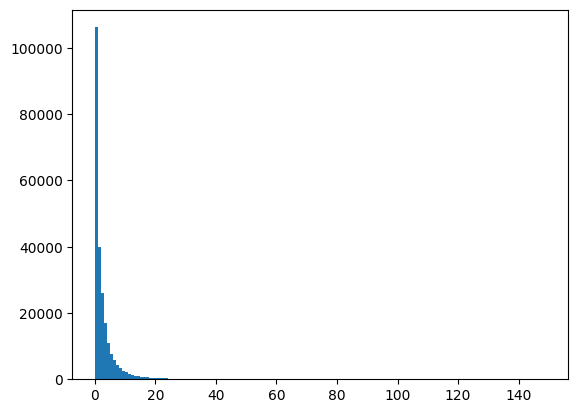

In [65]:
train_data = models.embeddings_datamodule.EmbeddingDataset(data_split='train', data_split_dirs=["MultiOrg_train_normal", "MultiOrg_train_macros", "OrgaSegment_train", "Tellu_train", "OrgaQuant_train"], backbone_name=backbone_name, decoder='FRCNNv2', num_queries=200)
plt.hist(train_data.metadata[['n_objects']], bins=np.arange(150))
print(len(train_data))

0it [00:00, ?it/s]


41620


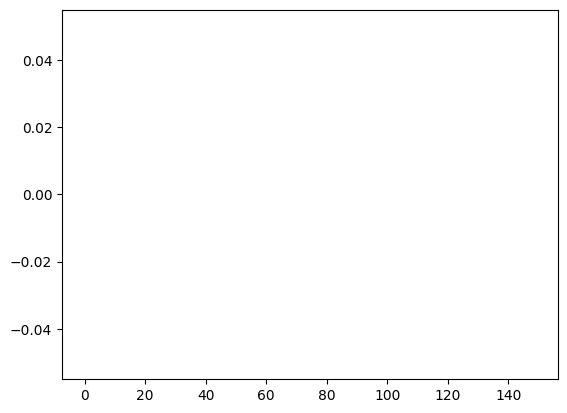

In [66]:
train_data_oi = models.embeddings_datamodule.EmbeddingDataset(data_split='train', data_split_dirs=["open_images_v4_5/original_data"], backbone_name=backbone_name, decoder='FRCNNv2', num_queries=200)
plt.hist(train_data_oi.metadata[['n_objects']], bins=np.arange(150))
print(len(train_data_oi))

23172it [00:57, 401.99it/s] 


23172


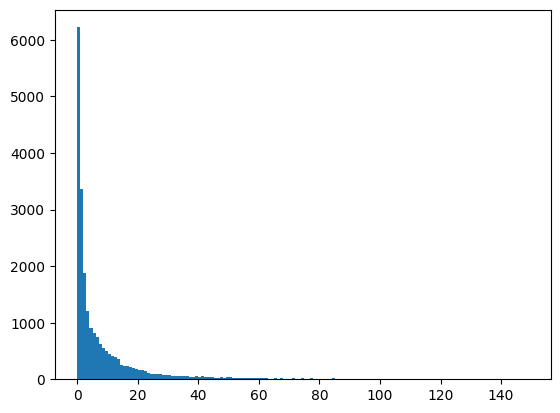

In [67]:
train_data_neurips = models.embeddings_datamodule.EmbeddingDataset(data_split='train', data_split_dirs=["NeurIPSCellSeg_train"], backbone_name=backbone_name, decoder='FRCNNv2', num_queries=200)
plt.hist(train_data_neurips.metadata[['n_objects']], bins=np.arange(150))
print(len(train_data_neurips))

0it [00:00, ?it/s]

23172it [00:03, 6144.45it/s] 


64792


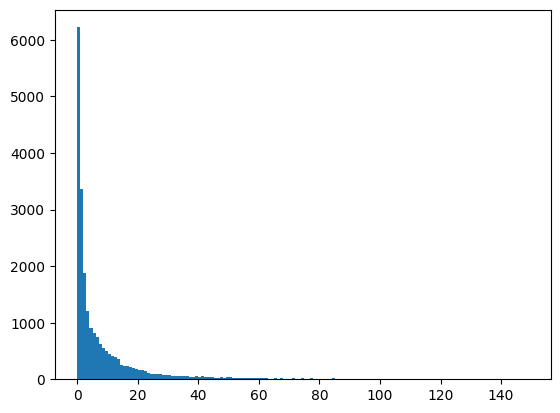

In [21]:
train_data_combined = models.embeddings_datamodule.EmbeddingDataset(data_split='train', data_split_dirs=["open_images_v4_5/original_data","NeurIPSCellSeg_train"], backbone_name=backbone_name, decoder='FRCNNv2', num_queries=200)
plt.hist(train_data_combined.metadata[['n_objects']], bins=np.arange(150))
print(len(train_data_combined))

In [ ]:
import models.detr_own_impl_model

In [27]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='SAM_large',)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 4929542


In [28]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='SAM2_large',)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 4929542


In [29]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='FM_concat',)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 5060870


In [30]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='SAM_large', num_layers_low_res=12)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 9674246


In [37]:
model = models.detr_own_impl_model.DetectionTransformer(backbone_name='SAM2_large', 
                                                        num_layers_low_res=11, 
                                                        num_layers_medium_res=6, 
                                                        num_layers_high_res=4)

n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Num trainable params (total):", n_parameters)

Num trainable params (total): 9610854


In [38]:
import models.embeddings_datamodule

backbone_name = 'SAM2_large'

datamodule = models.embeddings_datamodule.EmbeddingDataModule(train_dirs=["open_images_v4_5/original_data","NeurIPSCellSeg_train"], val_dirs=['NeurIPSCellSeg_val'], batch_size=2, batches_per_epoch=5,use_sampler=True,sampling_groups=['n_objects'], backbone_name=backbone_name, decoder='DETR_own_implementation', num_queries=200)

TypeError: EmbeddingDataModule.__init__() missing 3 required positional arguments: 'test_dirs', 'max_oversampling', and 'n_validation_samples'

In [70]:
res = train_data[1000]

In [71]:
res = train_data_oi[2980]

In [72]:
res = train_data_neurips[0]

In [73]:
res = train_data_combined[460]

In [74]:
res[0][0].shape, res[0][1].shape, res[0][2].shape, res[1], res[2:]

(torch.Size([1, 512, 64, 64]),
 torch.Size([1, 64, 128, 128]),
 torch.Size([1, 32, 256, 256]),
 {'boxes': tensor([], size=(0, 4)),
  'labels': tensor([], dtype=torch.int64),
  'image_id': tensor([460]),
  'area': tensor([]),
  'is_crowd': tensor([], dtype=torch.bool),
  'orig_size': tensor([512, 512]),
  'size': tensor([512, 512])},
 ('im_cell_00009_512', array([ 12, 512, 509]), (512, 512), 12))

### weighted sampling distributions

237264it [02:40, 1475.50it/s]


(array([1.06195e+05, 3.98750e+04, 2.61750e+04, 1.69210e+04, 1.09920e+04,
        7.74000e+03, 5.86600e+03, 4.37800e+03, 3.39200e+03, 2.55700e+03,
        2.04500e+03, 1.69000e+03, 1.33400e+03, 1.10700e+03, 9.35000e+02,
        7.55000e+02, 6.57000e+02, 5.66000e+02, 5.28000e+02, 4.24000e+02,
        3.74000e+02, 3.13000e+02, 2.51000e+02, 2.39000e+02, 1.88000e+02,
        1.65000e+02, 1.45000e+02, 1.21000e+02, 1.03000e+02, 9.90000e+01,
        8.50000e+01, 8.20000e+01, 7.70000e+01, 6.20000e+01, 6.60000e+01,
        2.70000e+01, 3.80000e+01, 4.50000e+01, 3.20000e+01, 3.80000e+01,
        1.80000e+01, 2.60000e+01, 2.60000e+01, 2.50000e+01, 1.00000e+01,
        2.50000e+01, 1.90000e+01, 1.60000e+01, 1.50000e+01, 1.60000e+01,
        1.50000e+01, 1.40000e+01, 8.00000e+00, 2.00000e+01, 1.30000e+01,
        1.00000e+01, 1.90000e+01, 1.00000e+01, 1.00000e+01, 1.00000e+01,
        8.00000e+00, 9.00000e+00, 3.00000e+00, 7.00000e+00, 7.00000e+00,
        0.00000e+00, 5.00000e+00, 3.00000e+00, 9.00

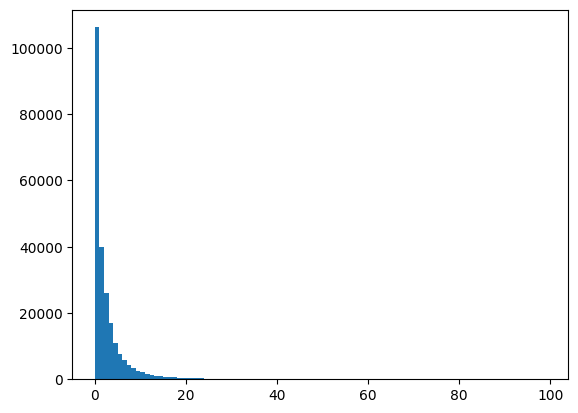

In [3]:
train_data = models.image_datamodule.ImageDataset(data_split='train', data_split_dirs=["MultiOrg_train_normal", "MultiOrg_train_macros", "OrgaSegment_train", "Tellu_train", "OrgaQuant_train"], backbone_name='FRCNN')
plt.hist(train_data.metadata[['n_objects']], bins=np.arange(100))

23172it [00:02, 10908.30it/s]


(array([6.221e+03, 3.370e+03, 1.876e+03, 1.205e+03, 9.020e+02, 8.210e+02,
        7.480e+02, 6.240e+02, 5.460e+02, 4.980e+02, 4.460e+02, 4.080e+02,
        3.990e+02, 3.520e+02, 2.590e+02, 2.420e+02, 2.330e+02, 2.150e+02,
        1.940e+02, 1.840e+02, 1.600e+02, 1.560e+02, 1.470e+02, 1.050e+02,
        1.000e+02, 9.800e+01, 9.800e+01, 9.900e+01, 7.300e+01, 7.900e+01,
        7.600e+01, 6.400e+01, 6.300e+01, 6.200e+01, 5.700e+01, 5.000e+01,
        5.900e+01, 4.000e+01, 4.000e+01, 5.300e+01, 4.800e+01, 5.000e+01,
        4.800e+01, 4.800e+01, 3.500e+01, 2.600e+01, 2.700e+01, 3.200e+01,
        1.700e+01, 3.200e+01, 3.500e+01, 3.000e+01, 2.100e+01, 3.000e+01,
        2.200e+01, 1.900e+01, 2.500e+01, 2.200e+01, 2.300e+01, 1.700e+01,
        2.200e+01, 2.600e+01, 1.600e+01, 1.000e+01, 1.300e+01, 2.000e+01,
        1.300e+01, 1.600e+01, 1.300e+01, 9.000e+00, 1.000e+01, 1.500e+01,
        1.100e+01, 1.000e+01, 1.700e+01, 1.000e+01, 8.000e+00, 1.500e+01,
        5.000e+00, 9.000e+00, 4.000e+0

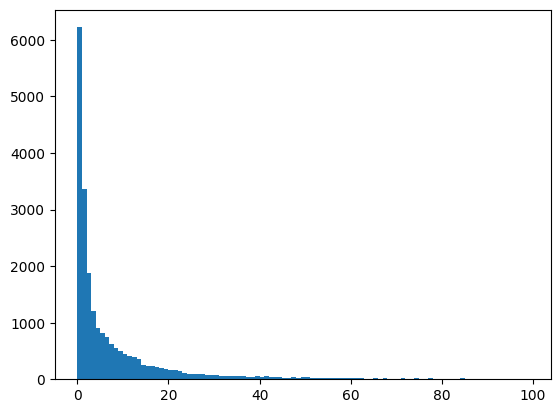

In [14]:
train_data = models.image_datamodule.ImageDataset(data_split='train', data_split_dirs=["open_images_v4_5/original_data", "NeurIPSCellSeg_train"], backbone_name='FRCNN')
plt.hist(train_data.metadata[['n_objects']], bins=np.arange(100))

start compute weights


Found Open Images samples in the data, assigning weight 0.5


(0,) weight 1.554602135339309e-07
(1,) weight 2.8697863157109323e-07
(2,) weight 5.155213157753646e-07
(3,) weight 8.025875422361694e-07
(4,) weight 1.0721928917900046e-06
(5,) weight 1.1779756253283608e-06
(6,) weight 1.292938487158535e-06
(7,) weight 1.5498685711451668e-06
(8,) weight 1.7712783670230478e-06
(9,) weight 1.942003992760209e-06
(10,) weight 2.168425982947498e-06
(11,) weight 2.370387226457314e-06
(12,) weight 2.4238546075052234e-06
(13,) weight 2.747494285211887e-06
(14,) weight 3.7340462872377766e-06
(15,) weight 3.996355323944562e-06
(16,) weight 4.150720980234267e-06
(17,) weight 4.4982232018352755e-06
(18,) weight 4.985144270075176e-06
(19,) weight 5.25607602388361e-06
(20,) weight 6.044487427466151e-06
(21,) weight 6.199474284580667e-06
(22,) weight 6.579033934657035e-06
(23,) weight 9.210647508519848e-06
(24,) weight 9.67117988394584e-06
(25,) weight 9.868550901985552e-06
(26,) we

(array([0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00096712, 0.00096712,
        0.00096712, 0.00096712, 0.00096712, 0.00

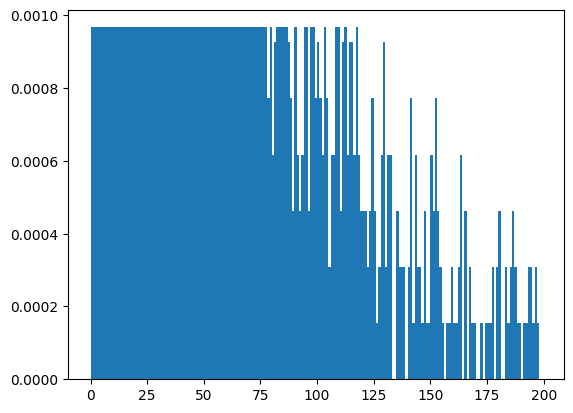

In [16]:
weights = models.image_datamodule.compute_weights(train_data.metadata, groups=['n_objects'], max_oversampling=10)
plt.hist(train_data.metadata[['n_objects']], bins=np.arange(200), weights=weights)

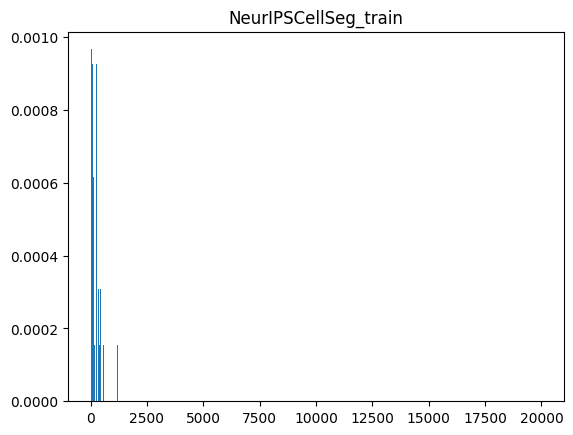

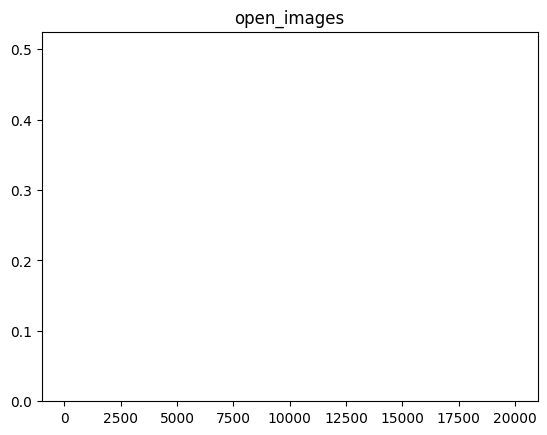

In [19]:
for ds in np.unique(train_data.metadata[['dataset']]):
    plt.figure()
    plt.title(ds)
    filter = (train_data.metadata[['dataset']].values==ds).flatten()
    plt.hist(train_data.metadata.loc[filter, ['n_objects']], bins=np.arange(200), weights=weights[filter])

In [2]:
image_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/orgasegment_test')

for ds_idx, ds in enumerate([dl.MultiOrg(split='test_macros'),
                             dl.OrganoID(split='test'),
                             dl.OrganoID(split='test_C'),
                             dl.OrganoID(split='test_Lung'),
                             dl.OrganoID(split='test_ACC'),
                             dl.OrganoID(split='test_only_mouse'),
                             dl.OrgaExtractor(split='all'),
                             dl.NewData(split='all'),
                             dl.OrgaSegment(split='test'),
                             dl.OrgaQuant(split='test'),
                             dl.Tellu(split='test'),
                             dl.MultiOrg(split='test_normal'),]):
    for i, (im, gt_mask, gt_boxes, im_path, im_ID) in enumerate(ds):
        im, flatfield = dl.normalize(im, correct_bg=False if str(ds).startswith('MultiOrg') else True)
        outfile = image_dir / f"{str(ds)}_{ds.split}__{im_ID}.png"
        assert not outfile.exists(), outfile
        cv2.imwrite(str(outfile), im)

In [ ]:
image_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/umamba_test/test_images')

for ds_idx, ds in enumerate([dl.MultiOrg(split='test_macros'),
                             dl.OrganoID(split='test'),
                             dl.OrganoID(split='test_C'),
                             dl.OrganoID(split='test_Lung'),
                             dl.OrganoID(split='test_ACC'),
                             dl.OrganoID(split='test_only_mouse'),
                             dl.OrgaExtractor(split='all'),
                             dl.NewData(split='all'),
                             dl.OrgaSegment(split='test'),
                             dl.OrgaQuant(split='test'),
                             dl.Tellu(split='test'),
                             dl.MultiOrg(split='test_normal'),]):
    for i, (im, gt_mask, gt_boxes, im_path, im_ID) in enumerate(ds):
        im, flatfield = dl.normalize(im, correct_bg=False if str(ds).startswith('MultiOrg') else True)
        outfile1 = image_dir / f"Dataset{ds_idx:03d}_{str(ds)}{ds.split}" / 'imagesTr' / f"image_{i:03d}_0000.png"
        outfile2 = image_dir / f"Dataset{ds_idx:03d}_{str(ds)}{ds.split}" / 'imagesTs' / f"image_{i:03d}_0000.png"
        outfile1.parent.mkdir(exist_ok=True, parents=True)
        outfile2.parent.mkdir(exist_ok=True, parents=True)
        cv2.imwrite(str(outfile1), im)
        cv2.imwrite(str(outfile2), im)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax, color='red'):
    y_min, x_min, y_max, x_max = box
    
    # Calculate width and height of the box
    width = x_max - x_min
    height = y_max - y_min

    ax.add_patch(plt.Rectangle((x_min, y_min), width, height, edgecolor=color, facecolor=(0,0,0,0), lw=2))

def show_mask(contour, ax, random_color=False):
    if random_color:
        color = np.random.random(3)
    else:
        color = np.array([30/255, 184/255, 255/255])
    edgecolor = np.concatenate([color, np.array([1.0])], axis=0)
    facecolor = np.concatenate([color, np.array([0.4])], axis=0)

    contour = gpd.GeoSeries(contour)
    contour.plot(edgecolor=edgecolor, facecolor=facecolor, ax=ax)

def visualize(im, contours, boxes, random_color=True, box_color='red', format='yxyx_px', ax=None, **fig_kwargs):
    # Format boxes
    H, W = im.shape[:2]

    if format=='cycxhw_01':
        # boxes are in cycxhw format normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes) * max(H, W)
    elif format=='cycxhw_px':
        # boxes are in cycxhw format in pixels. Converts to min/max coordinates in pixels.
        original_boxes = cxcywh_to_xyxy(boxes)
    elif format=='yxyx_01':
        # boxes are in min/max coordinates normalized by the longest image side. Converts to min/max coordinates in pixels.
        original_boxes = boxes * max(H, W)
    elif format=='yxyx_px':
        # boxes are in min/max coordinates in pixels. No conversion necessary.
        original_boxes = boxes
    else:
        raise ValueError(format)

    if ax is None:
        fig, ax = plt.subplots(1, 1, **fig_kwargs)
    
    ax.imshow(im)
    ax.axis(False)
    for i in range(original_boxes.shape[0]):
        show_mask(contours[i], ax, random_color=random_color)
        show_box(original_boxes[i], ax, color=box_color)

### Test mAP metric

In [14]:
# # ssd_model = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-last_epoch=799-val_loss=17.95.ckpt')
# ssd_model = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200-last_epoch=799-val_loss=2.85.ckpt')
# samos_model = SAMOS(checkpoint_path='/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_added_eval_True_32_200/DetectionHead_SAM_large_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_added_eval_True_32_200-last_epoch=799-val_loss=4.93.ckpt')
# rcnn_model = FasterRCNNPredictor(checkpoint_path='/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/FasterRCNN/FasterRCNNv2_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_FasterRCNN_16012025_True_16_200/FasterRCNNv2_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_FasterRCNN_16012025_True_16_200-last_epoch=649-val_loss=0.28.ckpt',
#                                  version_FasterRCNN='v2')
# cellpose_model = Cellpose(diameter=None)
# gtsam_model = GroundTruthSAM(sam_version='sam2', box_noise_std=0, box_noise_bias=0)
pred_sam_model = PredictionSAM(sam_version='sam1', logging_name="SSD_default_MultiOrg_train_normal_MultiOrg_train_macros_OrgaSegment_train_Tellu_train_OrgaQuant_train_20022025_baseline_ssd_sampling_n_objects_True_8_200_2025")

/home/icb/lion.gleiter/projects/organoid_sam/segment-anything/segment-anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

In [ ]:
plot_dir = results_dir / 'zeroshot' / 'visualizations'
plot_dir.mkdir(exist_ok=True, parents=True)

for ds in [dl.OrgaExtractor(split='test'),
           dl.Tellu(split='test'),
           dl.OrgaQuant(split='test'),
           dl.OrgaSegment(split='test'),
           dl.OrganoID(split='test'),
           dl.OrganoID(split='test_only_mouse'),
           dl.OrganoID(split='test_C'),
           dl.OrganoID(split='test_ACC'),
           dl.OrganoID(split='test_Lung'),
           dl.NewData(split='all'),
           dl.MultiOrg(split='train_normal')]:
    for idx in [0, 3]:
        im, gt_mask, gt_boxes, im_path, im_ID = ds[idx]
        im, flatfield = dl.normalize(im, correct_bg=False if str(ds).startswith('MultiOrg') else True)
        print(im.shape)

        for diameter in ([None],
                         [30],
                         [100],
                         [300],
                         [100, 300]):
            cellpose_model.diameter = diameter
            contours_cellpose, boxes_cellpose, scores_cellpose = cellpose_model.forward(im, patch_size=512, predict_masks=True, 
                                                                                        min_diameter=30/1.29 if str(ds).startswith('MultiOrg') else 10)
            
            # Visualize boxes
            fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
            plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
            plot_boxes(im, boxes_cellpose, format='yxyx_px', ax=ax, show_image=False, color='red')
            ax.axis(False)

            # Define custom line handles
            line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
            line_c = mlines.Line2D([], [], color='red', label='Cellpose', linewidth=2)

            # Add legend with custom handles
            plt.legend(handles=[line_a, line_c])
            plt.savefig(plot_dir / f'{str(ds)}_{ds.split}_idx_{idx}_cellpose_{diameter}_boxes.png', dpi=300)
            plt.savefig(plot_dir / f'{str(ds)}_{ds.split}_idx_{idx}_cellpose_{diameter}_boxes.pdf', dpi=300)
            plt.close('all')
            
            # Visualize masks
            fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
            ax.imshow(im)
            ax.axis(False)
            for i in range(boxes_cellpose.shape[0]):
                show_mask(contours_cellpose[i], ax, random_color=True)
            plt.savefig(plot_dir / f'{str(ds)}_{ds.split}_idx_{idx}_cellpose_{diameter}_masks.png', dpi=300)
            plt.savefig(plot_dir / f'{str(ds)}_{ds.split}_idx_{idx}_cellpose_{diameter}_masks.pdf', dpi=300)
            plt.close('all')

(1200, 1600, 3)
(1200, 1600, 3)
(960, 1280, 3)
(960, 1280, 3)
(450, 450, 3)
(450, 450, 3)
(1024, 1024, 3)
(1024, 1024, 3)
(1528, 1672, 3)
(1022, 1024, 3)
(1944, 2592, 3)
(1944, 2592, 3)
(1022, 1024, 3)
(1022, 1024, 3)
(750, 750, 3)
(700, 700, 3)
(1022, 1024, 3)
(1022, 1024, 3)
(2048, 2048, 3)
(2048, 2048, 3)
(5720, 6384, 3)


In [ ]:
1+1

In [27]:
# ds = dl.OrgaExtractor(split='test')
# ds = dl.Tellu(split='test')
# ds = dl.OrgaQuant(split='test')
ds = dl.OrgaSegment(split='test')
# ds = dl.OrganoID(split='test')
# ds = dl.OrganoID(split='test_only_mouse')
# ds = dl.OrganoID(split='test_C')
# ds = dl.OrganoID(split='test_ACC')
# ds = dl.OrganoID(split='test_Lung')
# ds = dl.NewData(split='all')
# ds = dl.MultiOrg(split='test_normal')
# ds = dl.MultiOrg(split='test_macros')

idx = 4
im, gt_mask, gt_boxes, im_path, im_ID = ds[idx]
im, flatfield = dl.normalize(im, correct_bg=False)
print(im.shape)

(512, 512, 3)


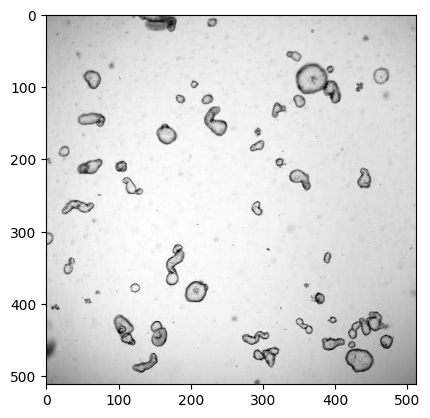

In [28]:
plt.imshow(im)

In [35]:
# contours_ssd, boxes_ssd, scores_ssd = ssd_model.forward(im, patch_size=512, predict_masks=True, min_diameter=30/1.29)
# contours_ssd, boxes_ssd, scores_ssd = ssd_model.set_threshold(0.5, predict_masks=True)
# contours_rcnn, boxes_rcnn, scores_rcnn = rcnn_model.forward(im, patch_size=512, predict_masks=True, min_diameter=30/1.29)
# contours_rcnn, boxes_rcnn, scores_rcnn = rcnn_model.set_threshold(0.5, predict_masks=True)
# contours_samos, boxes_samos, scores_samos = samos_model.forward(im, patch_size=512, predict_masks=True, min_diameter=30/1.29)
# contours_samos, boxes_samos, scores_samos = samos_model.set_threshold(0.9, predict_masks=True)
# cellpose_model.diameter = (100, 300)
# contours_cellpose, boxes_cellpose, scores_cellpose = cellpose_model.forward(im, patch_size=512, predict_masks=True, min_diameter=10)
# contours_cellpose, boxes_cellpose, scores_cellpose = cellpose_model.set_threshold(0.9, predict_masks=True)
# gtsam_model.box_noise_std = 0
# gtsam_model.box_noise_bias = 2
# contours_cellpose, boxes_cellpose, scores_cellpose = gtsam_model.forward(im, gt_boxes, patch_size=(512, 1024), predict_masks=True, min_diameter=10)
contours_cellpose, boxes_cellpose, scores_cellpose = pred_sam_model.forward(f'{str(ds)}_{ds.split}', im_ID, predict_masks=True, min_diameter=10)
# contours_cellpose, boxes_cellpose, scores_cellpose = gtsam_model.set_threshold(0.9, predict_masks=True)

/ictstr01/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head/util/pred_with_sam.py:169: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_embedding = torc

NameError: name 'show_mask' is not defined

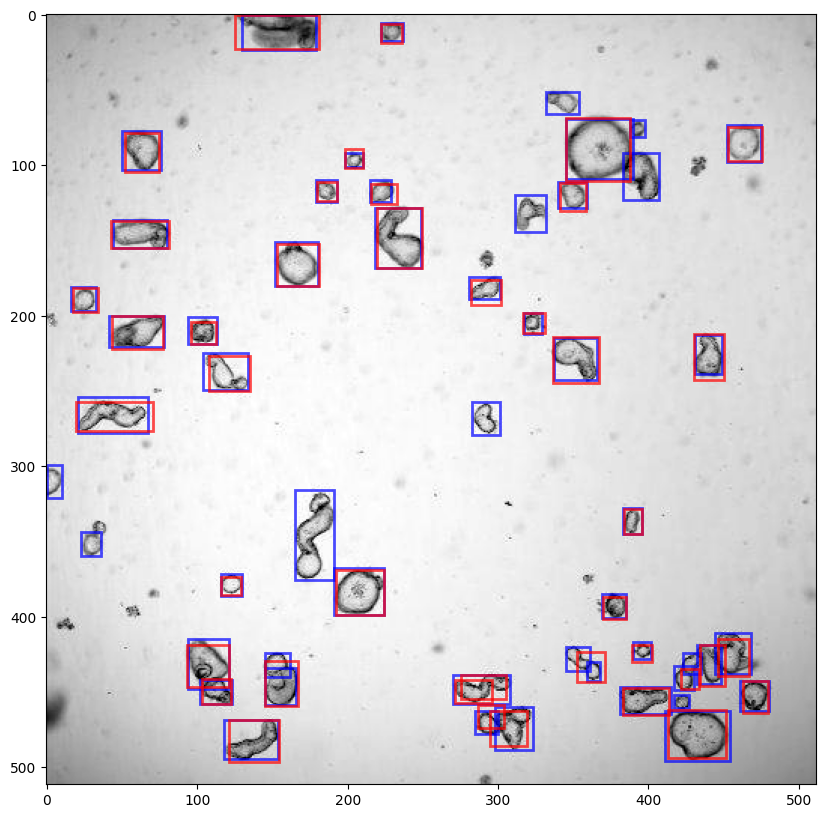

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
# i = 10
# plot_boxes(im, gt_boxes[i:i+1], format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_cellpose, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(boxes_cellpose.shape[0]):
    show_mask(contours_cellpose[i], ax, random_color=True)

# show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='SSD', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

In [37]:
len(ds)

12

In [38]:
boxes_cellpose.shape

(41, 4)

In [41]:
pred_sam_model.pred_boxes.shape

(59150, 4)

In [2]:
import sys
sys.path.append('/home/icb/lion.gleiter/projects/organoid_sam/sam2')

In [ ]:

# from sam2.build_sam import build_sam2
# from sam2.sam2_image_predictor import SAM2ImagePredictor


# device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
checkpoint_name = "/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints/sam2.1_hiera_large.pt"
config_name = "configs/sam2.1/sam2.1_hiera_l.yaml"
sam2 = build_sam2(config_name, checkpoint=checkpoint_name, device=device)
# sam2.eval()
sam_predictor = SAM2ImagePredictor(sam2)
# sam_predictor.reset_state()

cfg {'model': {'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforwar

In [10]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

sam_predictor = SAM2ImagePredictor(sam2_model)

cfg {'model': {'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforwar

In [31]:
cfg_test = "cfg {'model': {'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforward': 2048, 'dropout': 0.1, 'pos_enc_at_attn': False, 'self_attention': {'_target_': 'sam2.modeling.sam.transformer.RoPEAttention', 'rope_theta': 10000.0, 'feat_sizes': [64, 64], 'embedding_dim': 256, 'num_heads': 1, 'downsample_rate': 1, 'dropout': 0.1}, 'd_model': 256, 'pos_enc_at_cross_attn_keys': True, 'pos_enc_at_cross_attn_queries': False, 'cross_attention': {'_target_': 'sam2.modeling.sam.transformer.RoPEAttention', 'rope_theta': 10000.0, 'feat_sizes': [64, 64], 'rope_k_repeat': True, 'embedding_dim': 256, 'num_heads': 1, 'downsample_rate': 1, 'dropout': 0.1, 'kv_in_dim': 64}}, 'num_layers': 4}, 'memory_encoder': {'_target_': 'sam2.modeling.memory_encoder.MemoryEncoder', 'out_dim': 64, 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 64, 'normalize': True, 'scale': None, 'temperature': 10000}, 'mask_downsampler': {'_target_': 'sam2.modeling.memory_encoder.MaskDownSampler', 'kernel_size': 3, 'stride': 2, 'padding': 1}, 'fuser': {'_target_': 'sam2.modeling.memory_encoder.Fuser', 'layer': {'_target_': 'sam2.modeling.memory_encoder.CXBlock', 'dim': 256, 'kernel_size': 7, 'padding': 3, 'layer_scale_init_value': 1e-06, 'use_dwconv': True}, 'num_layers': 2}}, 'num_maskmem': 7, 'image_size': 1024, 'sigmoid_scale_for_mem_enc': 20.0, 'sigmoid_bias_for_mem_enc': -10.0, 'use_mask_input_as_output_without_sam': True, 'directly_add_no_mem_embed': True, 'no_obj_embed_spatial': True, 'use_high_res_features_in_sam': True, 'multimask_output_in_sam': True, 'iou_prediction_use_sigmoid': True, 'use_obj_ptrs_in_encoder': True, 'add_tpos_enc_to_obj_ptrs': True, 'proj_tpos_enc_in_obj_ptrs': True, 'use_signed_tpos_enc_to_obj_ptrs': True, 'only_obj_ptrs_in_the_past_for_eval': True, 'pred_obj_scores': True, 'pred_obj_scores_mlp': True, 'fixed_no_obj_ptr': True, 'multimask_output_for_tracking': True, 'use_multimask_token_for_obj_ptr': True, 'multimask_min_pt_num': 0, 'multimask_max_pt_num': 1, 'use_mlp_for_obj_ptr_proj': True, 'compile_image_encoder': False, 'sam_mask_decoder_extra_args': {'dynamic_multimask_via_stability': True, 'dynamic_multimask_stability_delta': 0.05, 'dynamic_multimask_stability_thresh': 0.98}}}"
cfg_working = "cfg {'model': {'_target_': 'sam2.modeling.sam2_base.SAM2Base', 'image_encoder': {'_target_': 'sam2.modeling.backbones.image_encoder.ImageEncoder', 'scalp': 1, 'trunk': {'_target_': 'sam2.modeling.backbones.hieradet.Hiera', 'embed_dim': 144, 'num_heads': 2, 'stages': [2, 6, 36, 4], 'global_att_blocks': [23, 33, 43], 'window_pos_embed_bkg_spatial_size': [7, 7], 'window_spec': [8, 4, 16, 8]}, 'neck': {'_target_': 'sam2.modeling.backbones.image_encoder.FpnNeck', 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 256, 'normalize': True, 'scale': None, 'temperature': 10000}, 'd_model': 256, 'backbone_channel_list': [1152, 576, 288, 144], 'fpn_top_down_levels': [2, 3], 'fpn_interp_model': 'nearest'}}, 'memory_attention': {'_target_': 'sam2.modeling.memory_attention.MemoryAttention', 'd_model': 256, 'pos_enc_at_input': True, 'layer': {'_target_': 'sam2.modeling.memory_attention.MemoryAttentionLayer', 'activation': 'relu', 'dim_feedforward': 2048, 'dropout': 0.1, 'pos_enc_at_attn': False, 'self_attention': {'_target_': 'sam2.modeling.sam.transformer.RoPEAttention', 'rope_theta': 10000.0, 'feat_sizes': [64, 64], 'embedding_dim': 256, 'num_heads': 1, 'downsample_rate': 1, 'dropout': 0.1}, 'd_model': 256, 'pos_enc_at_cross_attn_keys': True, 'pos_enc_at_cross_attn_queries': False, 'cross_attention': {'_target_': 'sam2.modeling.sam.transformer.RoPEAttention', 'rope_theta': 10000.0, 'feat_sizes': [64, 64], 'rope_k_repeat': True, 'embedding_dim': 256, 'num_heads': 1, 'downsample_rate': 1, 'dropout': 0.1, 'kv_in_dim': 64}}, 'num_layers': 4}, 'memory_encoder': {'_target_': 'sam2.modeling.memory_encoder.MemoryEncoder', 'out_dim': 64, 'position_encoding': {'_target_': 'sam2.modeling.position_encoding.PositionEmbeddingSine', 'num_pos_feats': 64, 'normalize': True, 'scale': None, 'temperature': 10000}, 'mask_downsampler': {'_target_': 'sam2.modeling.memory_encoder.MaskDownSampler', 'kernel_size': 3, 'stride': 2, 'padding': 1}, 'fuser': {'_target_': 'sam2.modeling.memory_encoder.Fuser', 'layer': {'_target_': 'sam2.modeling.memory_encoder.CXBlock', 'dim': 256, 'kernel_size': 7, 'padding': 3, 'layer_scale_init_value': 1e-06, 'use_dwconv': True}, 'num_layers': 2}}, 'num_maskmem': 7, 'image_size': 1024, 'sigmoid_scale_for_mem_enc': 20.0, 'sigmoid_bias_for_mem_enc': -10.0, 'use_mask_input_as_output_without_sam': True, 'directly_add_no_mem_embed': True, 'no_obj_embed_spatial': True, 'use_high_res_features_in_sam': True, 'multimask_output_in_sam': True, 'iou_prediction_use_sigmoid': True, 'use_obj_ptrs_in_encoder': True, 'add_tpos_enc_to_obj_ptrs': True, 'proj_tpos_enc_in_obj_ptrs': True, 'use_signed_tpos_enc_to_obj_ptrs': True, 'only_obj_ptrs_in_the_past_for_eval': True, 'pred_obj_scores': True, 'pred_obj_scores_mlp': True, 'fixed_no_obj_ptr': True, 'multimask_output_for_tracking': True, 'use_multimask_token_for_obj_ptr': True, 'multimask_min_pt_num': 0, 'multimask_max_pt_num': 1, 'use_mlp_for_obj_ptr_proj': True, 'compile_image_encoder': False, 'sam_mask_decoder_extra_args': {'dynamic_multimask_via_stability': True, 'dynamic_multimask_stability_delta': 0.05, 'dynamic_multimask_stability_thresh': 0.98}}}"

In [32]:
cfg_test == cfg_working

True

In [82]:
im.shape

(1024, 1024, 3)

In [ ]:
sam_predictor.set_image(im)

In [102]:
!wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/truck.jpg

--2025-02-17 12:50:13--  https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/truck.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 271475 (265K) [image/jpeg]
Saving to: ‘images/truck.jpg’

truck.jpg           100%[===================>] 265.11K  1.14MB/s    in 0.2s    

2025-02-17 12:50:16 (1.14 MB/s) - ‘images/truck.jpg’ saved [271475/271475]



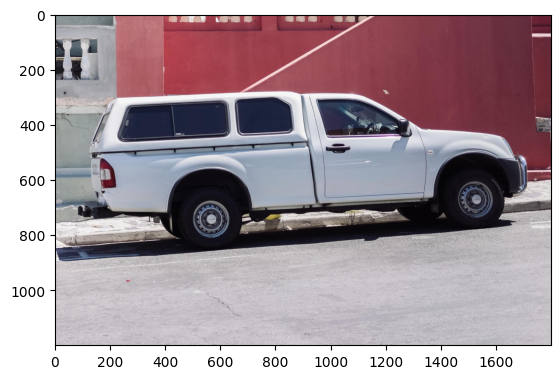

In [4]:
im2 = cv2.imread('images/truck.jpg')
im2 = cv2.cvtColor(im2, cv2.COLOR_RGB2BGR)
plt.imshow(im2)

In [11]:
im2.shape, im2.min(), im2.max(), im2.dtype

((1200, 1800, 3), 0, 255, dtype('uint8'))

In [11]:
sam_predictor.set_image(im2[:512, :512])

In [5]:
gtsam_model.sam_predictor.set_image(im2[:512, :512])

In [7]:
input_point = np.array([[510, 220]])
input_label = np.array([1])

In [16]:
input_point = np.array([[500, 375]])
input_label = np.array([1])

In [8]:
input_box = gt_boxes[0]
# # transformed_boxes = input_box[None, :]
transformed_boxes = np.array([[input_box[1], input_box[0], input_box[3], input_box[2]]])
# with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
masks, scs, _ = gtsam_model.sam_predictor.predict(
    point_coords=None,
    point_labels=None,
    box=transformed_boxes,
    multimask_output=False,
)
# masks, scs, _ = sam_predictor.predict(
#     point_coords=input_point,
#     point_labels=input_label,
#     multimask_output=False,
# )

In [16]:
masks.shape

(1, 512, 512)

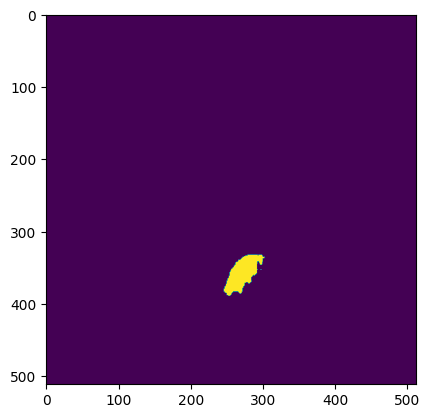

In [9]:
plt.imshow(masks[0])

In [48]:
contours_samos, boxes_samos, scores_samos = samos_model.set_threshold(0.7, predict_masks=True)

In [11]:
print(gt_boxes.shape, boxes_cellpose.shape, boxes_cellpose.shape, scores_cellpose, scores_cellpose, len(ds), type(boxes_cellpose))

(36, 4) (1, 4) (1, 4) [1.] [1.] 12 <class 'numpy.ndarray'>


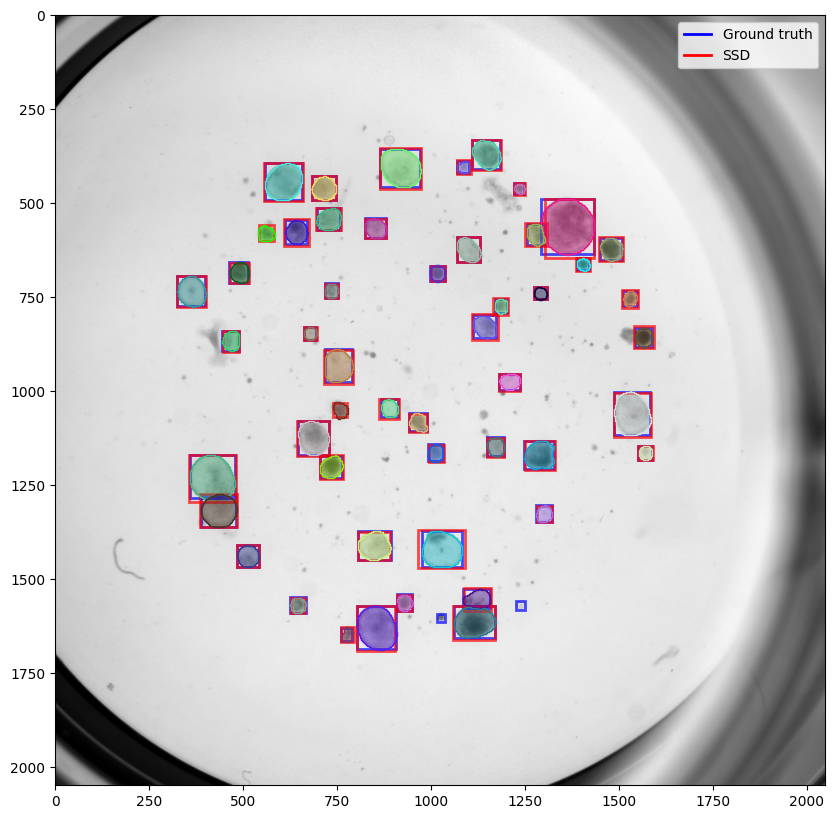

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_cellpose, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(boxes_cellpose.shape[0]):
    show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='SSD', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

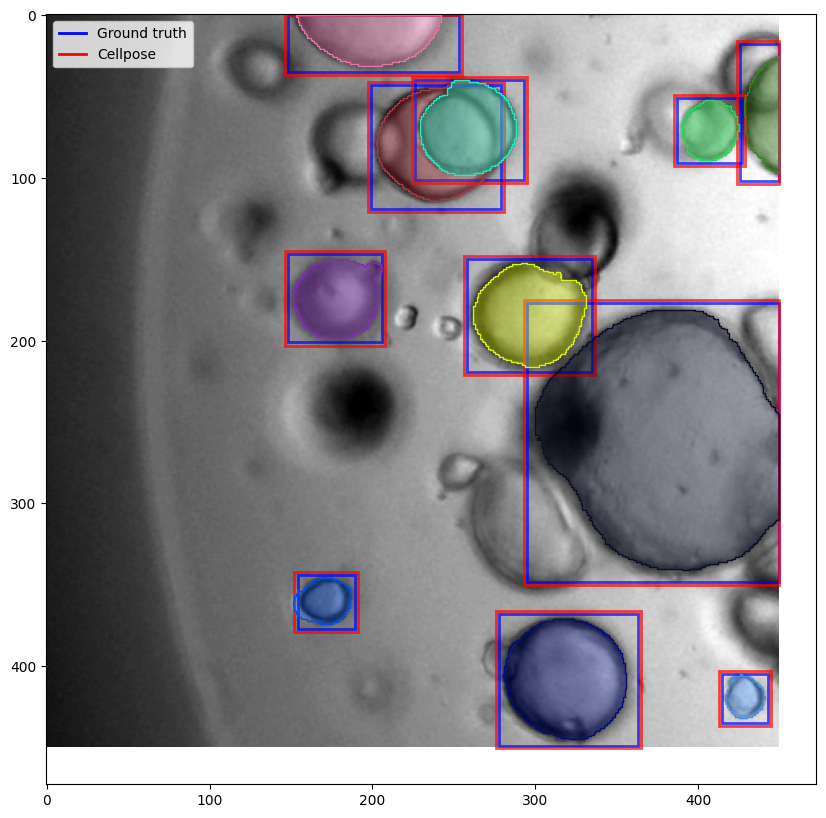

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_cellpose, format='yxyx_px', ax=ax, show_image=False, color='red')

# Plot mask predictions
for i in range(boxes_cellpose.shape[0]):
    show_mask(contours_cellpose[i], ax, random_color=True)

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_c = mlines.Line2D([], [], color='red', label='Cellpose', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_c])

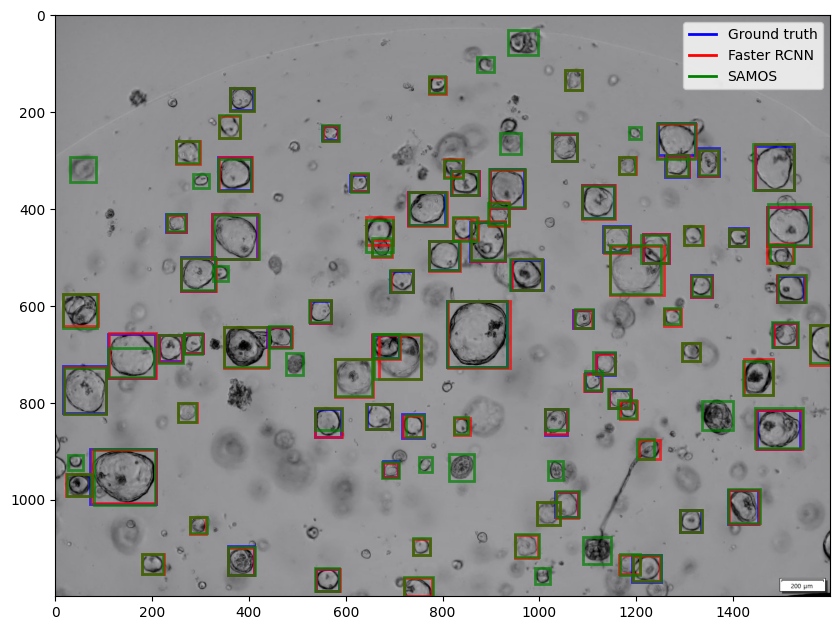

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_rcnn, format='yxyx_px', ax=ax, show_image=False, color='red')
plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, show_image=False, color='green')

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_b = mlines.Line2D([], [], color='red', label='Faster RCNN', linewidth=2)
line_c = mlines.Line2D([], [], color='green', label='SAMOS', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_b, line_c])

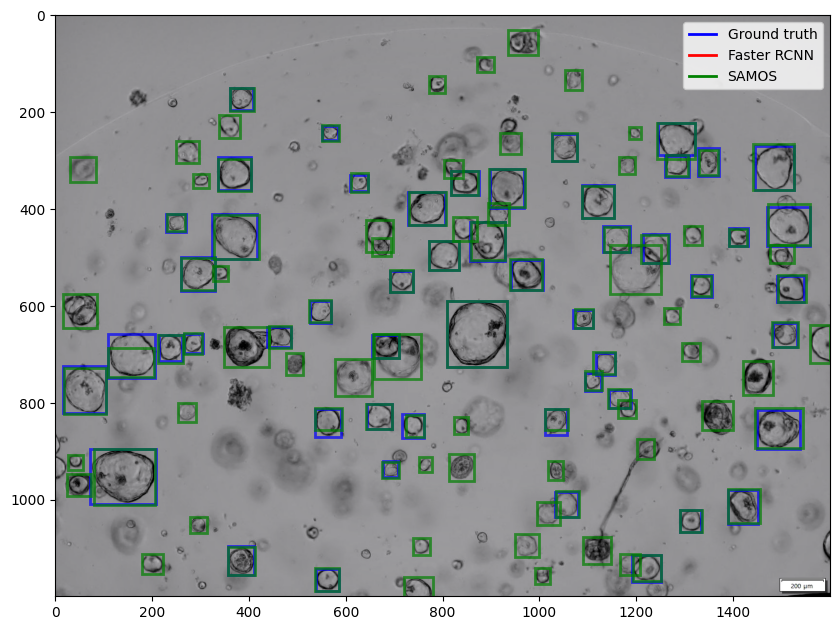

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
# plot_boxes(im, boxes_rcnn, format='yxyx_px', ax=ax, show_image=False, color='red')
plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, show_image=False, color='green')

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_b = mlines.Line2D([], [], color='red', label='Faster RCNN', linewidth=2)
line_c = mlines.Line2D([], [], color='green', label='SAMOS', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_b, line_c])

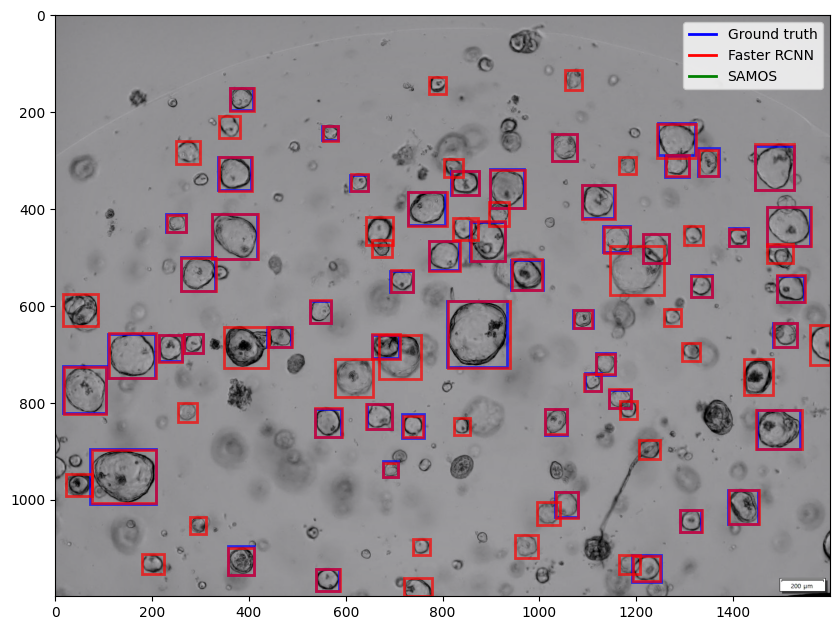

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_rcnn, format='yxyx_px', ax=ax, show_image=False, color='red')
# plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, show_image=False, color='green')

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_b = mlines.Line2D([], [], color='red', label='Faster RCNN', linewidth=2)
line_c = mlines.Line2D([], [], color='green', label='SAMOS', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_b, line_c])

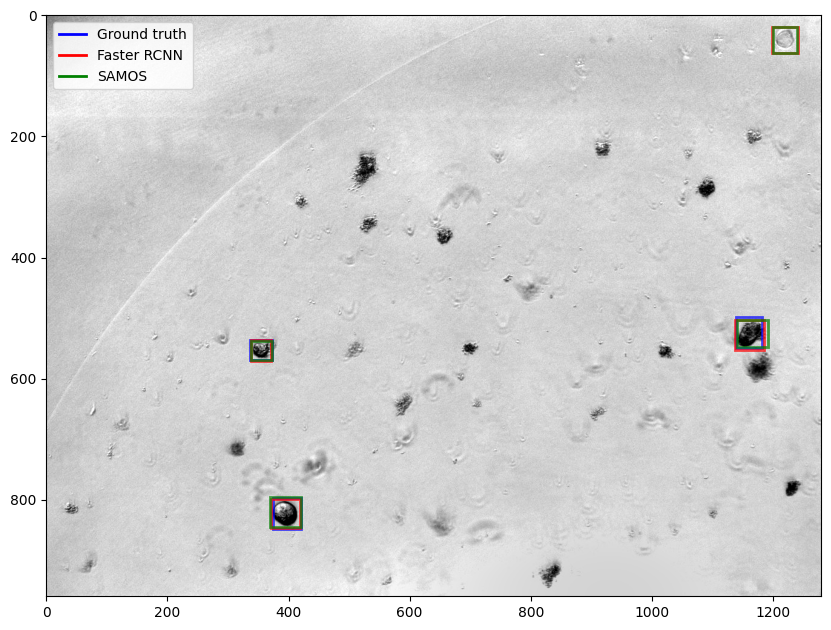

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes_rcnn, format='yxyx_px', ax=ax, show_image=False, color='red')
plot_boxes(im, boxes_samos, format='yxyx_px', ax=ax, show_image=False, color='green')

# Define custom line handles
line_a = mlines.Line2D([], [], color='blue', label='Ground truth', linewidth=2)
line_b = mlines.Line2D([], [], color='red', label='Faster RCNN', linewidth=2)
line_c = mlines.Line2D([], [], color='green', label='SAMOS', linewidth=2)

# Add legend with custom handles
plt.legend(handles=[line_a, line_b, line_c])

In [12]:
gt_masks = pp.convert_mask_to_binary(gt_mask)

In [17]:
# Segmentation metric implementation
iou_matrix = pp.compute_iou_matrix_segmentation_contours(contours_rcnn, gt_masks=gt_masks)
mAP_scores, haussdorf_scores, haussdorf_95_scores, masd_scores, assd_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_segmentation_all(
    iou_matrix, [0.5, 0.75, 0.9], scores_rcnn, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], gt_masks, contours_rcnn
)
mAP_scores, haussdorf_scores, haussdorf_95_scores

([0.9249772311573218, 0.8980636201770418, 0.14630684655199735],
 [4.087731369788056, 4.048613111738837, 3.9425111914758237],
 [3.3441004220818646, 3.304079551786715, 3.0675109268819343])

In [18]:
# Segmentation metric implementation
iou_matrix = pp.compute_iou_matrix_segmentation_contours(contours_samos, gt_masks=gt_masks)
mAP_scores, haussdorf_scores, haussdorf_95_scores, masd_scores, assd_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_segmentation_all(
    iou_matrix, [0.5, 0.75, 0.9], scores_samos, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], gt_masks, contours_samos
)
mAP_scores, haussdorf_scores, haussdorf_95_scores

([0.8243159170088088, 0.7488047301293386, 0.08847399758194362],
 [5.071001134159821, 4.4738411795262145, 3.9531785995137834],
 [4.261208691015424, 3.6906570386560418, 3.0142537208554363])

In [ ]:
# Own mAP implementation
iou_matrix = pp.compute_iou_matrix_detection(boxes_rcnn, gt_boxes)
mAP_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_detection_all(
    iou_matrix, [0.5, 0.75, 0.9], scores_rcnn, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
)
mAP_scores, f1_scores

([0.9170796485840113, 0.691717680388123, 0.06077839991920227],
 [0.8864864864864865,
  0.8864864864864865,
  0.8864864864864865,
  0.8864864864864865,
  0.8864864864864865,
  0.8756756756756756,
  0.8648648648648649,
  0.8540540540540539,
  0.8216216216216217])

In [52]:
# Own mAP implementation
iou_matrix = pp.compute_iou_matrix_detection(boxes_samos, gt_boxes)
mAP_scores, pq_scores, iou_scores, dice_scores, f1_scores, prec_scores, recall_scores = pp.compute_metrics_detection_all(
    iou_matrix, [0.5, 0.75, 0.9], scores_samos, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
)
mAP_scores, f1_scores

([0.8832957466886817, 0.6040942830834048, 0.02039117769454848],
 [0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8307692307692307,
  0.8205128205128206,
  0.7794871794871795,
  0.7282051282051282])

In [40]:
import torchmetrics.detection

mAP_metric = torchmetrics.detection.MeanAveragePrecision(class_metrics=True, extended_summary=False, backend='faster_coco_eval',)

In [41]:
mAP_metric.update(preds=[{'boxes': torch.from_numpy(boxes_rcnn), 
                          'scores': torch.from_numpy(scores_rcnn), 
                          'labels': torch.zeros(scores_rcnn.shape, dtype=torch.int)}], 
                  target=[{'boxes': torch.from_numpy(gt_boxes), 
                           'labels': torch.zeros((gt_boxes.shape[0],), dtype=torch.int)}])
res = mAP_metric.compute()
mAP_metric.reset()
res

{'map': tensor(0.5954),
 'map_50': tensor(0.9159),
 'map_75': tensor(0.6911),
 'map_small': tensor(0.1576),
 'map_medium': tensor(0.6360),
 'map_large': tensor(-1.),
 'mar_1': tensor(0.0079),
 'mar_10': tensor(0.0865),
 'mar_100': tensor(0.6427),
 'mar_small': tensor(0.2125),
 'mar_medium': tensor(0.6852),
 'mar_large': tensor(-1.),
 'map_per_class': tensor(0.5954),
 'mar_100_per_class': tensor(0.6427),
 'classes': tensor(0, dtype=torch.int32)}

In [42]:
mAP_metric.update(preds=[{'boxes': torch.from_numpy(boxes_samos), 
                          'scores': torch.from_numpy(scores_samos), 
                          'labels': torch.zeros(scores_samos.shape, dtype=torch.int)}], 
                  target=[{'boxes': torch.from_numpy(gt_boxes), 
                           'labels': torch.zeros((gt_boxes.shape[0],), dtype=torch.int)}])
res = mAP_metric.compute()
mAP_metric.reset()
res

{'map': tensor(0.5183),
 'map_50': tensor(0.8333),
 'map_75': tensor(0.5852),
 'map_small': tensor(0.1545),
 'map_medium': tensor(0.5566),
 'map_large': tensor(-1.),
 'mar_1': tensor(0.0090),
 'mar_10': tensor(0.0843),
 'mar_100': tensor(0.5640),
 'mar_small': tensor(0.1500),
 'mar_medium': tensor(0.6049),
 'mar_large': tensor(-1.),
 'map_per_class': tensor(0.5183),
 'mar_100_per_class': tensor(0.5640),
 'classes': tensor(0, dtype=torch.int32)}

In [38]:
iou_matrix = np.array([
    [0.3, 0.5, 0.1, 0.74, 0.0, 0.0],
    [0.3, 0.5, 0.1, 0.04, 0.0, 0.0],
    [0.9, 0.5, 0.6, 0.04, 0.2, 0.0],
    [0.9, 0.5, 0.1, 0.04, 0.0, 0.02],
    [0.95, 0.6, 0.0, 0.04, 0.0, 0.1],
])
scores = np.array([0.08, 0.61, 0.33, 0.59, 0.97])

In [39]:
compute_metrics_detection_all(iou_matrix, [0.5, 0.75, 0.9], scores, thresholds=[0.1, 0.5, 0.9])

is_true_match [ True  True False  True  True]
ap 0.6
is_true_match [ True False False False False]
ap 0.16666666666666666
is_true_match [ True False False False False]
ap 0.16666666666666666
cost_matrix [[-0.95 -0.6  -0.   -0.04 -0.   -0.1 ]
 [-0.3  -0.5  -0.1  -0.04 -0.   -0.  ]
 [-0.9  -0.5  -0.1  -0.04 -0.   -0.02]
 [-0.9  -0.5  -0.6  -0.04 -0.2  -0.  ]]
row_ind, col_ind [0 1 2 3] [1 3 0 2]
matched_ious [0.6  0.04 0.9  0.6 ]
tp_ious [0.6 0.9 0.6]
tp 3
fp 2
fn 3
cost_matrix [[-0.95 -0.6  -0.   -0.04 -0.   -0.1 ]
 [-0.3  -0.5  -0.1  -0.04 -0.   -0.  ]
 [-0.9  -0.5  -0.1  -0.04 -0.   -0.02]]
row_ind, col_ind [0 1 2] [1 2 0]
matched_ious [0.6 0.1 0.9]
tp_ious [0.6 0.9]
tp 2
fp 3
fn 4
cost_matrix [[-0.95 -0.6  -0.   -0.04 -0.   -0.1 ]]
row_ind, col_ind [0] [0]
matched_ious [0.95]
tp_ious [0.95]
tp 1
fp 4
fn 5


([0.6, 0.16666666666666666, 0.16666666666666666],
 [0.0, 0.0, 0.0],
 [0.7000000000000001, 0.75, 0.95],
 [0.8157894736842105, 0.8486842105263157, 0.9743589743589743],
 [0.5454545454545454, 0.3636363636363636, 0.1818181818181818],
 [0.6, 0.4, 0.2],
 [0.5, 0.3333333333333333, 0.16666666666666666])

In [54]:
ds = dl.OrgaExtractor(split='test')

idx = 7
im, gt_mask, gt_boxes, im_path, im_ID = ds[idx]
# im, flatfield = dl.normalize(im)
print(im.shape)
im = (im / im.max() * 255).astype(np.uint8)
# im = np.stack((im, im, im), axis=2)
im = Image.fromarray(im).convert('RGB')
im = transforms(im)

(1200, 1600, 3)


In [18]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model_last = SSD.load_from_checkpoint('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-last_epoch=799-val_loss=17.95.ckpt')
model_best = SSD.load_from_checkpoint('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-best_epoch=49-val_loss=3.79.ckpt')

model_last.to(device)
model_best.to(device)

SSD(
  (model): SSD(
    (backbone): SSDFeatureExtractorVGG(
      (features): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (6): ReLU(inplace=True)
        (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (8): ReLU(inplace=True)
        (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (11): ReLU(inplace=True)
        (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (13): ReLU(inplace=True)
        (14): Conv2d(256, 256, kernel_size=(3, 3), stride

In [35]:
model_last.eval()
model_best.eval()
image = image.to(device)

with torch.inference_mode():
    output = model_last([image])
    # output = model_best([image])
output

{'pred_scores': tensor([1.0000, 0.9228, 0.6150, 0.2914], device='cuda:0'),
 'pred_boxes': tensor([[ 11.6078, 352.3887,  52.4829, 389.7431],
         [340.7168, 230.9342, 374.5117, 266.2815],
         [225.4310,  54.4283, 268.1337,  97.1424],
         [290.3765, 304.6036, 326.0614, 343.8856]], device='cuda:0')}

In [36]:
boxes = output['pred_boxes'].cpu().numpy()
# xyxy to yxyx
boxes = np.stack((boxes[:, 1], boxes[:, 0], boxes[:, 3], boxes[:, 2]), axis=1)
scores = output['pred_scores'].cpu().numpy()
boxes

array([[352.3887  ,  11.607782, 389.7431  ,  52.482933],
       [230.93425 , 340.71677 , 266.28152 , 374.51175 ],
       [ 54.42835 , 225.431   ,  97.14239 , 268.13367 ],
       [304.60358 , 290.3765  , 343.8856  , 326.0614  ]], dtype=float32)

In [37]:
filtered_boxes = boxes[scores > 0.5]

In [ ]:
im = image.cpu().numpy().transpose((1, 2, 0))

fig, ax = plt.subplots(1, 1, figsize=(12*4, 12*4), dpi=200)
# plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, filtered_boxes, format='yxyx_px', ax=ax, show_image=True, color='red')

## Full image patched predictions

In [3]:
# ssd_last = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-last_epoch=799-val_loss=17.95.ckpt')
# ssd_best = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_full_data_True_32_200-best_epoch=49-val_loss=3.79.ckpt')

/home/icb/lion.gleiter/projects/organoid_sam/segment-anything/segment-anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

In [3]:
ssd_full_best = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200-best_epoch=274-val_loss=2.81.ckpt')
ssd_multiorg_best = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_data_09012025_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_data_09012025_True_32_200-best_epoch=174-val_loss=3.30.ckpt')

/home/icb/lion.gleiter/projects/organoid_sam/segment-anything/segment-anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

In [3]:
ssd_full_last = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200/SSD_OrganoID_train_MultiOrg_train_macros_MultiOrg_train_normal_OrgaExtractor_train_OrgaQuant_train_OrgaSegment_train_Tellu_train_NewData_train_full_data_09012025_True_32_200-last_epoch=799-val_loss=2.85.ckpt')
# ssd_multiorg_last = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_data_09012025_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_data_09012025_True_32_200-last_epoch=799-val_loss=3.44.ckpt')

ssd_multiorg_last_multiscale = SSDPredictor('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/checkpoints_trained/SSD/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_with_090_overlap_True_32_200/SSD_MultiOrg_train_macros_MultiOrg_train_normal_multiorg_with_090_overlap_True_32_200-last_epoch=799-val_loss=3.13.ckpt')


/home/icb/lion.gleiter/projects/organoid_sam/segment-anything/segment-anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = 

In [4]:
ds = dl.MultiOrg(split='test_normal')

idx = 0
im, gt_mask, gt_boxes, im_path, im_ID = ds[idx]
# im, flatfield = dl.normalize(im)
im = (im / im.max() * 255).astype(np.uint8)
im = np.stack((im, im, im), axis=2)

In [5]:
im.shape

(6240, 6940, 3)

In [ ]:
# contours, boxes, scores = ssd_full_best.forward(im, patch_size=(350, 1024), predict_masks=True, min_diameter=30/1.29)
contours, boxes, scores = ssd_full_best.forward(im, patch_size=3000, predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([167, 4])
patch 0
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 1
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([169, 4])
patch 2
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 3
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([166, 4])
patch 4
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([162, 4])
patch 5
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([169, 4])
patch 6
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([164, 4])
patch 7
predict_boxes image.shape (3000, 3000, 3)
transformed_boxes.shape torch.Size([162, 4])


In [15]:
contours, boxes, scores = ssd_full_best.set_threshold(0.3, predict_masks=True)
print(scores)

[1.         0.99999988 0.99999988 0.99999976 0.99999797 0.99999607
 0.99999487 0.99999428 0.99999225 0.99997783 0.99996412 0.99996042
 0.99994969 0.99985611 0.99985099 0.99980336 0.99969494 0.99932122
 0.99926668 0.99855667 0.99846625 0.99811172 0.99751353 0.99720436
 0.99601609 0.99551219 0.99523783 0.99205011 0.98083329 0.97840607
 0.97013342 0.9689396  0.95700544 0.9349826  0.93196398 0.9223243
 0.91390014 0.86110312 0.84573722 0.83187973 0.82218403 0.81311071
 0.81228423 0.79938006 0.7842108  0.77655768 0.74996358 0.74563563
 0.72631687 0.63502741 0.6205768  0.61465025 0.57966256 0.579436
 0.54960358 0.54600894 0.53404206 0.50812072 0.49403211 0.49240822
 0.48420301 0.47576657 0.46808451 0.46325746 0.44200799 0.43589824
 0.43154091 0.38332582 0.38126099 0.3779268  0.37292609 0.3593221
 0.35728246 0.35703686 0.35399228 0.35344833 0.31938463 0.30854324
 0.30770457 0.30015725]


In [ ]:
boxes.shape, gt_boxes.shape

((80, 4), (176, 4))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

In [16]:
contours, boxes, scores = ssd_multiorg_best.forward(im, patch_size=(350, 1024), predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])


patch 0
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 1
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 2
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 3
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 4
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 5
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 6
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 7
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 8
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 9
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([200, 4])
patch 10
predict_boxes image.shape (350, 350, 3)
transformed_boxes.sha

In [23]:
contours, boxes, scores = ssd_multiorg_best.set_threshold(0.2, predict_masks=True)

In [24]:
boxes.shape, gt_boxes.shape

((230, 4), (176, 4))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

### last

In [6]:
contours, boxes, scores = ssd_full_last.forward(im, patch_size=(350, 1024, 2048, 4096), predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 0
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 1
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 2
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 3
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 4
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 5
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 6
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 7
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 8
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([170, 4])
patch 9
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.

In [7]:
contours, boxes, scores = ssd_full_last.set_threshold(0.3, predict_masks=True)
print(scores)

[1.         1.         1.         1.         1.         1.
 1.         1.         1.         0.99999988 0.99999988 0.99999964
 0.9999994  0.99999917 0.99999917 0.99999857 0.99999487 0.99999321
 0.99999261 0.99999201 0.99998224 0.9999609  0.99995029 0.99994707
 0.99994671 0.99994195 0.99994135 0.99992633 0.99990666 0.99990499
 0.99977595 0.9996525  0.99951732 0.99941826 0.99895334 0.99878985
 0.99859864 0.99763405 0.99684542 0.99591941 0.99358046 0.99348676
 0.99337924 0.99295747 0.99272352 0.99021405 0.98803467 0.9864369
 0.98623788 0.98292589 0.97742772 0.97482163 0.9736163  0.97074878
 0.96758491 0.96671093 0.96151733 0.95411026 0.94062769 0.93814886
 0.92760217 0.92262584 0.91377598 0.90502715 0.88616854 0.86707819
 0.85889691 0.82371336 0.81339896 0.80852675 0.79257989 0.77879989
 0.77093238 0.76466757 0.7629419  0.73777378 0.72944111 0.71849954
 0.70655751 0.69590759 0.68435884 0.6667307  0.64917505 0.6428057
 0.64250422 0.64229578 0.63909179 0.63600987 0.61843455 0.6003738
 0.589

In [8]:
boxes.shape, gt_boxes.shape

((138, 4), (176, 4))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

In [11]:
contours, boxes, scores = ssd_multiorg_last.forward(im, patch_size=(350, 1024), predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 0
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])


patch 1
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 2
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 3
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 4
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 5
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 6
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 7
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 8
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 9
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 10
predict_boxes image.shape (350, 350, 3)
transformed_boxes.shape torch.Size([160, 4])
patch 11
predict_boxes image.shape (350, 350, 3)
transformed_boxes.sh

In [21]:
contours, boxes, scores = ssd_multiorg_last.set_threshold(0.5, predict_masks=True)

In [22]:
boxes.shape, gt_boxes.shape

((85, 4), (176, 4))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

Multiscale training with > 0.9 overlap

In [20]:
# contours, boxes, scores = ssd_full_best.forward(im, patch_size=(350, 1024), predict_masks=True, min_diameter=30/1.29)
contours, boxes, scores = ssd_multiorg_last_multiscale.forward(im, patch_size=(512, 2048), predict_masks=True, min_diameter=30/1.29)

predict_boxes image.shape (512, 512, 3)


transformed_boxes.shape torch.Size([102, 4])
patch 0
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 1
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 2
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 3
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 4
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 5
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 6
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 7
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 8
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 9
predict_boxes image.shape (512, 512, 3)
transformed_boxes.shape torch.Size([102, 4])
patch 10
predict_boxes im

In [21]:
contours, boxes, scores = ssd_multiorg_last_multiscale.set_threshold(0.2, predict_masks=True)
print(scores)

[0.99993074 0.99975067 0.9996599  0.99962449 0.99954283 0.99952006
 0.99948055 0.99926883 0.99920779 0.99900407 0.99876714 0.99819404
 0.99698323 0.99663842 0.99622846 0.99473298 0.99427718 0.99025434
 0.98884064 0.98818249 0.98783827 0.98548156 0.98415947 0.9800337
 0.97540534 0.97466362 0.97440058 0.97069442 0.96738005 0.96686065
 0.96209109 0.95618409 0.94792861 0.94407165 0.94340944 0.93130118
 0.9235636  0.91748995 0.91351187 0.90499991 0.90070653 0.89924455
 0.89075124 0.86891329 0.86695921 0.84105492 0.83506143 0.82969105
 0.82334405 0.82194817 0.80887204 0.74606252 0.74224138 0.72918588
 0.72456622 0.72400069 0.71979022 0.71829969 0.70477057 0.69807905
 0.69752133 0.69025379 0.67531663 0.6719588  0.64987749 0.63869476
 0.62774575 0.59901369 0.57982659 0.57726473 0.55560368 0.54559636
 0.5354588  0.51658624 0.51557213 0.51289439 0.5089218  0.49978268
 0.49553049 0.47711989 0.46545178 0.43933541 0.42228264 0.41938457
 0.40887669 0.40780407 0.39914876 0.39763007 0.38808149 0.38662

In [22]:
boxes.shape, gt_boxes.shape

((130, 4), (176, 4))

In [ ]:
# (512, 2048)
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

In [ ]:
# (512, 1024, 2048, 4096)
fig, ax = plt.subplots(1, 1, figsize=(12*2, 12*2), dpi=200)
plot_boxes(im, gt_boxes, format='yxyx_px', ax=ax, color='blue')
plot_boxes(im, boxes, format='yxyx_px', ax=ax, show_image=False, color='red')

In [24]:
!python --version

Python 3.11.5


In [29]:
import sys
sys.version_info

sys.version_info(major=3, minor=11, micro=5, releaselevel='final', serial=0)